In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load AFDC Data (alt_fuel_stations_ev_charging_units (Nov 20 2024)) as a Pandas DataFrame
df = pd.read_csv('alt_fuel_stations_ev_charging_units (Nov 20 2024).csv', usecols=['Station Name', 'Street Address', 'City', 'State', 'EV Level2 EVSE Num', 'EV DC Fast Count', 'EV J1772 Connector Count', 'EV J1772 Power Output (kW)', 'EV CCS Connector Count', 'EV CCS Power Output (kW)', 'EV CHAdeMO Connector Count', 'EV CHAdeMO Power Output (kW)', 'EV J3400 Connector Count', 'EV J3400 Power Output (kW)'])
print(df.head())
print(df.info())
print(df.describe())

                    Station Name      Street Address         City State  \
0       LADWP - Truesdale Center  11797 Truesdale St   Sun Valley    CA   
1       LADWP - Truesdale Center  11797 Truesdale St   Sun Valley    CA   
2       LADWP - Truesdale Center  11797 Truesdale St   Sun Valley    CA   
3  Los Angeles Convention Center  1201 S Figueroa St  Los Angeles    CA   
4  Los Angeles Convention Center  1201 S Figueroa St  Los Angeles    CA   

   EV Level2 EVSE Num  EV DC Fast Count  EV J1772 Connector Count  \
0                57.0               2.0                         0   
1                57.0               2.0                         0   
2                57.0               2.0                        57   
3                 7.0               NaN                         1   
4                 7.0               NaN                         1   

   EV J1772 Power Output (kW)  EV CCS Connector Count  \
0                         NaN                       1   
1                   

In [3]:
# Keep only San Francisco, CA rows
df = df[(df['City'] == 'San Francisco') & (df['State'] == 'CA')]

In [10]:
# Check if each unique station name's mean value EV Level2 EVSE Num is consistent with its sum of EV J1772 Connector Count
# Filter away rows where EV J3400 Power Output (kW) is above 20 kW
print(len(df))
df_level2 = df[~(df['EV J3400 Power Output (kW)'] > 20)]
print(len(df_level2))
df_gb_level2 = df_level2.groupby('Station Name')[['EV Level2 EVSE Num', 'EV J1772 Connector Count', 'EV J3400 Connector Count']].agg(['median', 'sum']).fillna(0)
df_gb_level2['Count by Level'] = df_gb_level2[('EV Level2 EVSE Num', 'median')]
df_gb_level2['Count by Connector'] = df_gb_level2[('EV J1772 Connector Count', 'sum')] + df_gb_level2[('EV J3400 Connector Count', 'sum')]

# Print rows where the two counts are inconsistent
x = df_gb_level2.loc[df_gb_level2['Count by Level'] != df_gb_level2['Count by Connector'], ['Count by Connector']]
y = df_gb_level2.loc[df_gb_level2['Count by Level'] != df_gb_level2['Count by Connector'], ['Count by Level']]
print(x.values-y.values)

print(len(x))

1248
1200
[[ 2.]
 [ 4.]
 [ 2.]
 [ 6.]
 [12.]
 [16.]]
6


In [11]:
# Check if each unique station name's mean value EV DC Fast Count is consistent with its sum of EV CCS Connector Count, EV CHAdeMO Connector Count, and EV J3400 Connector Count
# Filter away rows where EV J3400 Power Output (kW) is below 20 kW
print(len(df))
df_dc = df[~(df['EV J3400 Power Output (kW)'] <= 20)]
print(len(df_dc))
df_gb_dc = df.groupby('Station Name')[['EV DC Fast Count', 'EV CCS Connector Count', 'EV CHAdeMO Connector Count', 'EV J3400 Connector Count']].agg(['median', 'sum']).fillna(0)
df_gb_dc['Count by Level'] = df_gb_dc[('EV DC Fast Count', 'median')]
df_gb_dc['Count by Connector'] = df_gb_dc[('EV CCS Connector Count', 'sum')] + df_gb_dc[('EV CHAdeMO Connector Count', 'sum')] + df_gb_dc[('EV J3400 Connector Count', 'sum')]

# Print rows where the two counts are inconsistent
x = df_gb_dc.loc[df_gb_dc['Count by Level'] != df_gb_dc['Count by Connector'], ['Count by Connector']]
y = df_gb_dc.loc[df_gb_dc['Count by Level'] != df_gb_dc['Count by Connector'], ['Count by Level']]
print(x.values-y.values)

print(len(x))

1248
1248
[[ 2.]
 [ 1.]
 [ 2.]
 [11.]
 [ 2.]
 [ 1.]
 [ 1.]
 [ 1.]
 [ 4.]
 [ 9.]
 [ 1.]
 [ 3.]
 [ 4.]
 [ 1.]
 [ 1.]
 [ 3.]
 [ 1.]
 [ 1.]
 [ 1.]
 [ 1.]
 [ 1.]
 [ 2.]
 [ 1.]
 [ 3.]
 [ 2.]
 [ 1.]
 [ 6.]
 [ 6.]
 [ 2.]
 [ 1.]
 [ 2.]
 [ 1.]
 [ 1.]
 [ 1.]
 [ 1.]
 [ 1.]
 [ 6.]
 [ 1.]
 [ 1.]
 [ 8.]
 [ 1.]
 [ 4.]
 [ 2.]
 [ 6.]
 [ 6.]
 [ 2.]
 [ 9.]
 [ 1.]
 [ 2.]
 [ 2.]
 [ 2.]
 [ 2.]
 [22.]
 [ 5.]]
54


In [12]:
# Get sorted values count of EV J1772 Power Output (kW) when EV J1772 Connector Count is greater than 0
df_j1772 = df[df['EV J1772 Connector Count'] > 0]
print(df_j1772['EV J1772 Power Output (kW)'].value_counts().sort_index())

5.0       1
5.1       1
6.2      50
6.5     514
6.6       2
6.7      46
6.8       3
7.2      45
7.7       1
8.6      26
9.0       2
9.6      50
10.4      1
10.8      6
12.0      1
13.0      1
16.7      1
19.0      4
21.6      1
Name: EV J1772 Power Output (kW), dtype: int64


In [13]:
# Get sorted values count of EV CCS Power Output (kW) when EV CCS Connector Count is greater than 0
df_ccs = df[df['EV CCS Connector Count'] > 0]
print(df_ccs['EV CCS Power Output (kW)'].value_counts().sort_index())


50.0     42
62.0     12
62.5      1
100.0    14
150.0     3
350.0    42
Name: EV CCS Power Output (kW), dtype: int64


In [14]:
# Get sorted values count of EV CHAdeMO Power Output (kW) when EV CHAdeMO Connector Count is greater than 0
df_chademo = df[df['EV CHAdeMO Connector Count'] > 0]
print(df_chademo['EV CHAdeMO Power Output (kW)'].value_counts().sort_index())


50.0     34
62.5     11
100.0    16
Name: EV CHAdeMO Power Output (kW), dtype: int64


In [15]:
# Get sorted values count of EV J3400 Power Output (kW) when EV J3400 Connector Count is greater than 0
df_j3400 = df[df['EV J3400 Connector Count'] > 0]
print(df_j3400['EV J3400 Power Output (kW)'].value_counts().sort_index())


62.0      2
72.0     12
250.0    34
Name: EV J3400 Power Output (kW), dtype: int64


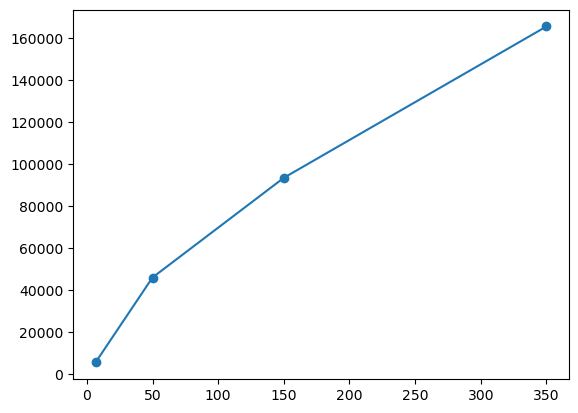

Cost per kW: [853.03030303 921.86       623.84666667 473.29714286]


In [16]:
power = np.array([6.6, 50, 150, 350])
cost_EVSE = np.array([2793, 28401, 75000, 140000])
cost_install = np.array([2837, 17692, 18577, 25654])
plt.plot(power, cost_EVSE + cost_install, 'o-')
plt.show()
print("Cost per kW: {}".format((cost_EVSE + cost_install) / power))


In [17]:
df_fast = df[df['EV DC Fast Count'] > 0].groupby('Station Name')[['EV DC Fast Count']].agg(['median']).fillna(0)
df_fast

,EV DC Fast Count
,median
Station Name,
101 LOMBARD ST LEVIS RAPID 2,1.0
2860 16th St,8.0
303 SECOND ST. KILROY DCFC 3,1.0
303 SECOND ST. KILROY DCFC 4,1.0
AMC Parking Lot Geary Blvd,9.0
Bay Area Metro Center,1.0
City Center - Tesla Supercharger,34.0
Design District,1.0


In [18]:
df[df['Station Name'] == 'Letterman Digital Arts Center - Tesla Supercharger']


,Station Name,Street Address,City,State,EV Level2 EVSE Num,EV DC Fast Count,EV J1772 Connector Count,EV J1772 Power Output (kW),EV CCS Connector Count,EV CCS Power Output (kW),EV CHAdeMO Connector Count,EV CHAdeMO Power Output (kW),EV J3400 Connector Count,EV J3400 Power Output (kW)
42536,Letterman Digital Arts Center - Tesla Supercha...,1 Letterman Drive,San Francisco,CA,NaN,6.0,0,NaN,0,NaN,0,NaN,1,NaN
42537,Letterman Digital Arts Center - Tesla Supercha...,1 Letterman Drive,San Francisco,CA,NaN,6.0,0,NaN,0,NaN,0,NaN,1,NaN
42538,Letterman Digital Arts Center - Tesla Supercha...,1 Letterman Drive,San Francisco,CA,NaN,6.0,0,NaN,0,NaN,0,NaN,1,NaN
42539,Letterman Digital Arts Center - Tesla Supercha...,1 Letterman Drive,San Francisco,CA,NaN,6.0,0,NaN,0,NaN,0,NaN,1,NaN
42540,Letterman Digital Arts Center - Tesla Supercha...,1 Letterman Drive,San Francisco,CA,NaN,6.0,0,NaN,0,NaN,0,NaN,1,NaN
42541,Letterman Digital Arts Center - Tesla Supercha...,1 Letterman Drive,San Francisco,CA,NaN,6.0,0,NaN,0,NaN,0,NaN,1,NaN


In [21]:
# Return list of stations where their connector count is nonzero but their power output is NaN
df_j1772.loc[(df_j1772['EV J1772 Power Output (kW)'].isna()), 'Station Name'].unique()

array(["Hyatt at Fisherman's Wharf", 'Palace Hotel',
       'Mark Hopkins InterContinental Hotel', 'Beach & Hyde Garage',
       'Golden Gate Park - Music Concourse Garage',
       'InterContinental Hotel - San Francisco',
       'San Francisco State University', 'Fort Mason',
       'JPMorgan Parking Garage', 'Extra Space Storage',
       'Golden Gate National Recreation Area - Fort Mason',
       'Caltrans - District 32', 'Fuse Project',
       'Department of Veterans Affairs VISN 21',
       'Hotel Kabuki, a Joie de Vivre Hotel - Tesla Destination',
       'The Ritz-Carlton Hotel San Francisco - Tesla Destination',
       'San Francisco Marriott Marquis - Tesla Destination',
       'The Fairmont San Francisco - Tesla Destination',
       'San Francisco Zoo - Tesla Destination', 'Bay Area Metro Center',
       'Fairmont Heritage Place Ghirardelli Square - Tesla Destination',
       'St. Ignatius College Preparatory', 'UCSF - 1630 3rd Garage',
       'China Basin - Tesla Destination',

In [22]:
df_ccs.loc[(df_ccs['EV CCS Power Output (kW)'].isna()), 'Station Name'].unique()

array(['SEC San Francisco'], dtype=object)

In [23]:
df_chademo.loc[(df_chademo['EV CHAdeMO Power Output (kW)'].isna()), 'Station Name'].unique()

array([], dtype=object)

In [24]:
df_j3400.loc[(df_j3400['EV J3400 Power Output (kW)'].isna()), 'Station Name'].unique()

array(['101 Second Street Garage - Tesla Destination',
       '101 California Street Garage - Tesla Destination',
       '345 California Center Parking Garage - Tesla Destination',
       'Hotel Kabuki, a Joie de Vivre Hotel - Tesla Destination',
       'Hotel Buchanan, a Kimpton Hotel - Tesla Destination',
       'Loews Regency San Francisco - Tesla Destination',
       'Hilton San Francisco Union Square - Tesla Destination',
       'The Westin St. Francis San Francisco on Union Square - Tesla Destination',
       'Park Central Hotel - Tesla Destination',
       'The Ritz-Carlton Hotel San Francisco - Tesla Destination',
       'San Francisco Marriott Marquis - Tesla Destination',
       'The Fairmont San Francisco - Tesla Destination',
       'InterContinental Mark Hopkins San Francisco - Tesla Destination',
       'San Francisco Zoo - Tesla Destination',
       'Fairmont Heritage Place Ghirardelli Square - Tesla Destination',
       'Letterman Digital Arts Center - Tesla Supercharge

In [ ]:
df.loc[df['Station Name'] == "Hyatt at Fisherman's Wharf", 'EV J1772 Power Output (kW)'] = 6
df.loc[df['Station Name'] == 'Palace Hotel', 'EV J1772 Power Output (kW)'] = 6.2
df.loc[df['Station Name'] == 'Mark Hopkins InterContinental Hotel', 'EV J1772 Power Output (kW)'] = np.nan
df.loc[df['Station Name'] == 'Beach & Hyde Garage', 'EV J1772 Power Output (kW)'] = 6.5

